In [1]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

d:\pypipeline\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
prds = pd.read_csv(r"D:\pypipeline\data\predictions\hourly\us_paro_hourly\test\hourly_pm25_predictions.csv")

TRAIN file: D:\pypipeline\data\processed\hourly\us_paro_hourly\train_processed.parquet
VAL file: D:\pypipeline\data\processed\hourly\us_paro_hourly\val_processed.parquet


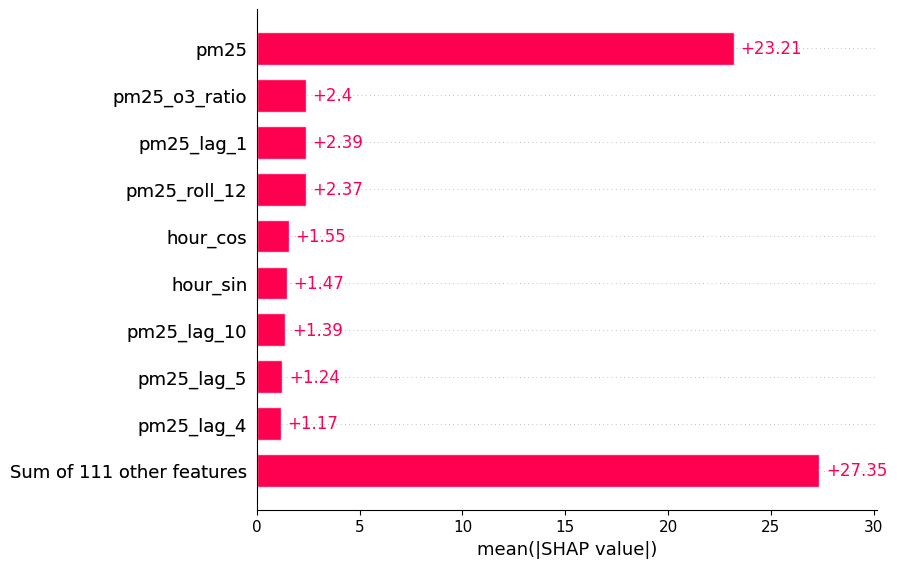

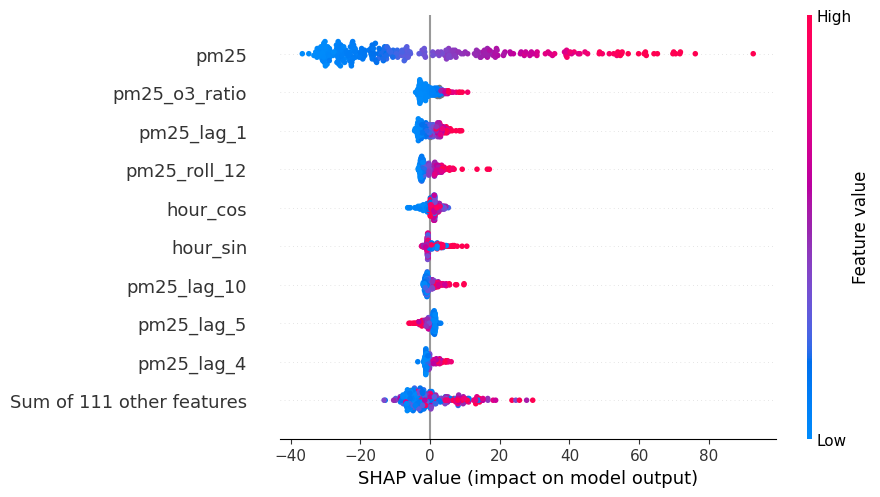

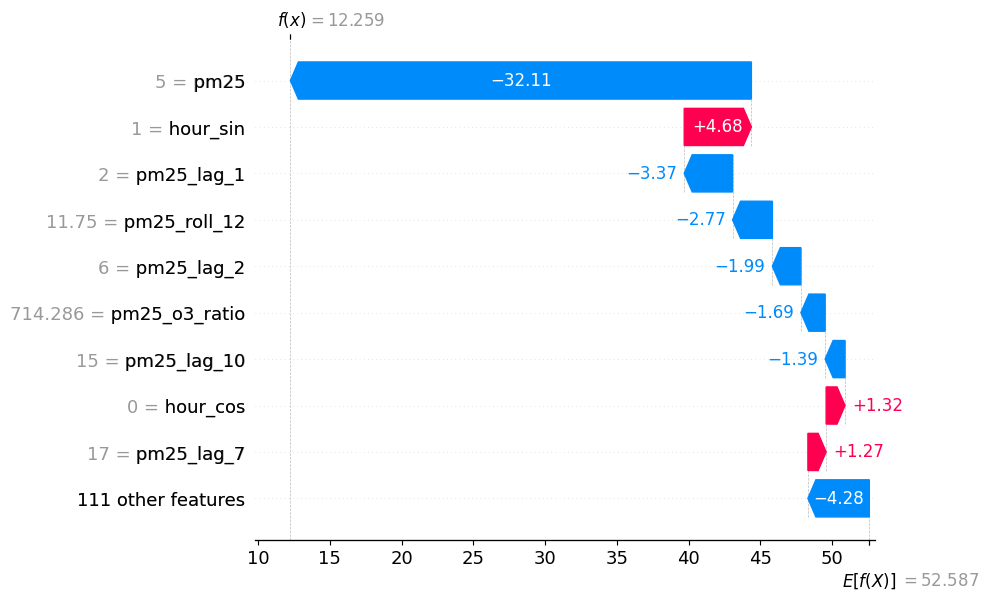

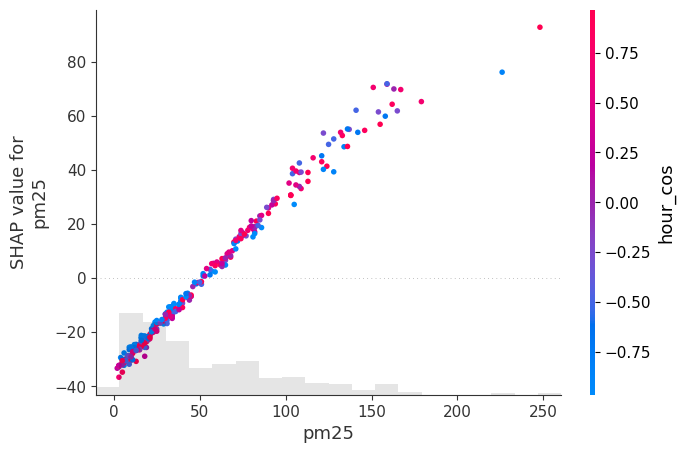

In [15]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import mlflow
import pandas as pd

# Simple local-path fix
DATA_PROCESSED_DIR = Path(r"D:/pypipeline/data/processed/hourly/us_paro_hourly")
VAL_PROCESSED_FILE = DATA_PROCESSED_DIR / "val_processed.parquet"
TRAIN_PROCESSED_FILE = DATA_PROCESSED_DIR / "train_processed.parquet"
TARGET_COL = os.getenv("TARGET_COL", "pm25")
HORIZON = 1
max_val = float(os.getenv("MAX_VAL", 500.0))
min_val = float(os.getenv("MIN_VAL", 0.0))

print("TRAIN file:", TRAIN_PROCESSED_FILE)
print("VAL file:", VAL_PROCESSED_FILE)

if not TRAIN_PROCESSED_FILE.exists():
    raise FileNotFoundError(f"Train file not found: {TRAIN_PROCESSED_FILE}")
if not VAL_PROCESSED_FILE.exists():
    raise FileNotFoundError(f"Validation file not found: {VAL_PROCESSED_FILE}")

features_exclude = [f"{TARGET_COL}_plus_{i}h" for i in range(1, HORIZON + 1)] + [
    f"o3_plus_{i}h" for i in range(1, HORIZON + 1)
] + [f"pm25_plus_{i}h" for i in range(1, HORIZON + 1)] + [
    "segment_id",
    "imputation_confidence",
    "pm25_target",
    "o3_target",
]

df_train = pd.read_parquet(TRAIN_PROCESSED_FILE)
df_val = pd.read_parquet(VAL_PROCESSED_FILE)

for h in range(1, HORIZON + 1):
    target_key = f"{TARGET_COL}_plus_{h}h"
    model_uri = f"models:/pm25_plus_{h}h_model/latest"
    model = mlflow.xgboost.load_model(model_uri)

    train_mask = (
        df_train[target_key].notnull()
        & (df_train[target_key] >= min_val)
        & (df_train[target_key] <= max_val)
    )
    eval_mask = (
        df_val[target_key].notnull()
        & (df_val[target_key] >= min_val)
        & (df_val[target_key] <= max_val)
    )

    X = df_train.loc[train_mask].drop(columns=features_exclude, errors="ignore").reset_index(drop=True)
    X_val = df_val.loc[eval_mask].drop(columns=features_exclude, errors="ignore").reset_index(drop=True)

    if X.empty or X_val.empty:
        print(f"Skipping {target_key}: no valid rows after filtering")
        continue

    bg_n = min(300, len(X))
    explain_n = min(300, len(X_val))
    X_bg = X.sample(n=bg_n, random_state=42)
    X_explain = X_val.sample(n=explain_n, random_state=42)

    explainer = shap.Explainer(model, X_bg)
    shap_values = explainer(X_explain)
    shap.plots.bar(shap_values, max_display=10)
    shap.plots.beeswarm(shap_values, max_display=10)
    shap.plots.waterfall(shap_values[0])
    shap.initjs()
    shap.plots.force(shap_values[0])

    feature_name= X_explain.columns[0]
    shap.plots.scatter(shap_values[:, feature_name], color=shap_values)
    plt.show()